### `Import The Main Libraries`

In [3]:
# main library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Machine Learning Library
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import f1_score, recall_score, accuracy_score, confusion_matrix, classification_report

# some Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier



### `Load the Dataset`

In [4]:
# Read the CSV File using Pandas
# data_path = os.path.join(os.getcwd(), 'health_lifestyle_dataset.csv')
df = pd.read_csv(r"Lifestyle_and_Health_Risk_Prediction_Synthetic_Dataset.csv")

# show the first 5 rows of the dataset
df.head()

,age,weight,height,exercise,sleep,sugar_intake,smoking,alcohol,married,profession,bmi,health_risk
0,56,67,195,low,6.1,medium,yes,yes,yes,office_worker,17.6,high
1,69,76,170,high,6.9,high,no,no,no,teacher,26.3,high
2,46,106,153,high,6.6,low,yes,no,no,artist,45.3,high
3,32,54,186,medium,8.5,medium,no,no,no,artist,15.6,low
4,60,98,195,high,8.0,low,no,no,yes,teacher,25.8,high


### `Explain the Features`

* `I Understood about these Featres:`

>> * `age: Age of the person in years`
>> * `weight: Body weight of the person in kilograms (kg)`
>> * `height: Height of the person in centimeters (cm)`
>> * `exercise: Level of physical activity -> values: low, medium, high`
>> * `sleep: Average number of hours the person sleeps per day`
>> * `sugar_intake: Amount of sugar consumption -> values: low, medium, high`
>> * `smoking: Indicates whether the person smokes -> values: yes, no`
>> * `alcohol: Indicates whether the person drinks alcohol -> values: yes, no`
>> * `married: Marital status of the person -> values: yes, no`
>> * `profession: Job or occupation of the person -> examples: office_worker, teacher, artist`
>> * `bmi: Body Mass Index calculated from weight and height used to estimate body fat and health condition`
>> * `health_risk: Target variable ->represents the health risk level of the person -> values: low, high`

* ` In simple words:`
* - `All these features are health-related factors used to predict whether a person has a risk of disease or not.`

### `Some Information on the Data`

In [5]:
# Shape of the Dataset
print("Shape of the Dataset:")
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Shape of the Dataset:
Number of Rows: 5000
Number of Columns: 12


In [6]:
## Some Information on (records_count, index_range, columns_count, is_null, data_type, memory_usage)
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           5000 non-null   int64  
 1   weight        5000 non-null   int64  
 2   height        5000 non-null   int64  
 3   exercise      5000 non-null   object 
 4   sleep         5000 non-null   float64
 5   sugar_intake  5000 non-null   object 
 6   smoking       5000 non-null   object 
 7   alcohol       5000 non-null   object 
 8   married       5000 non-null   object 
 9   profession    5000 non-null   object 
 10  bmi           5000 non-null   float64
 11  health_risk   5000 non-null   object 
dtypes: float64(2), int64(3), object(7)
memory usage: 468.9+ KB


In [7]:
# Show Statistical Description of Numerical Columns
print("Statistical Description of Numerical Columns:")
df.describe().T

Statistical Description of Numerical Columns:


,count,mean,std,min,25%,50%,75%,max
age,5000.0,48.80560,17.906991,18.0,34.0,49.0,64.0,79.0
weight,5000.0,77.35920,18.714567,45.0,61.0,77.0,94.0,109.0
height,5000.0,171.93320,15.822225,145.0,158.0,171.5,186.0,199.0
sleep,5000.0,6.99706,1.432849,3.0,6.0,7.0,8.0,10.0
bmi,5000.0,26.84388,8.252490,11.4,20.3,26.0,32.4,51.4


* `I note:`

>> * `Dataset contains 100,000 records with no missing values`
>> * `disease_risk mean = 0.248 → around 25% positive cases (class imbalance)`
>> * `Average BMI = 29 → close to obesity range`
>> * `Average cholesterol = 224 → higher than normal (risk indicator)`
>> * `Average systolic BP = 134 → pre-hypertension level`
>> * `Average sleep = 6.5 hours → slightly below recommended`
>> * `20% smokers in dataset`
>> * `30% alcohol consumption rate`
>> * `Data looks realistic with reasonable min and max values`

### Data Cleaning

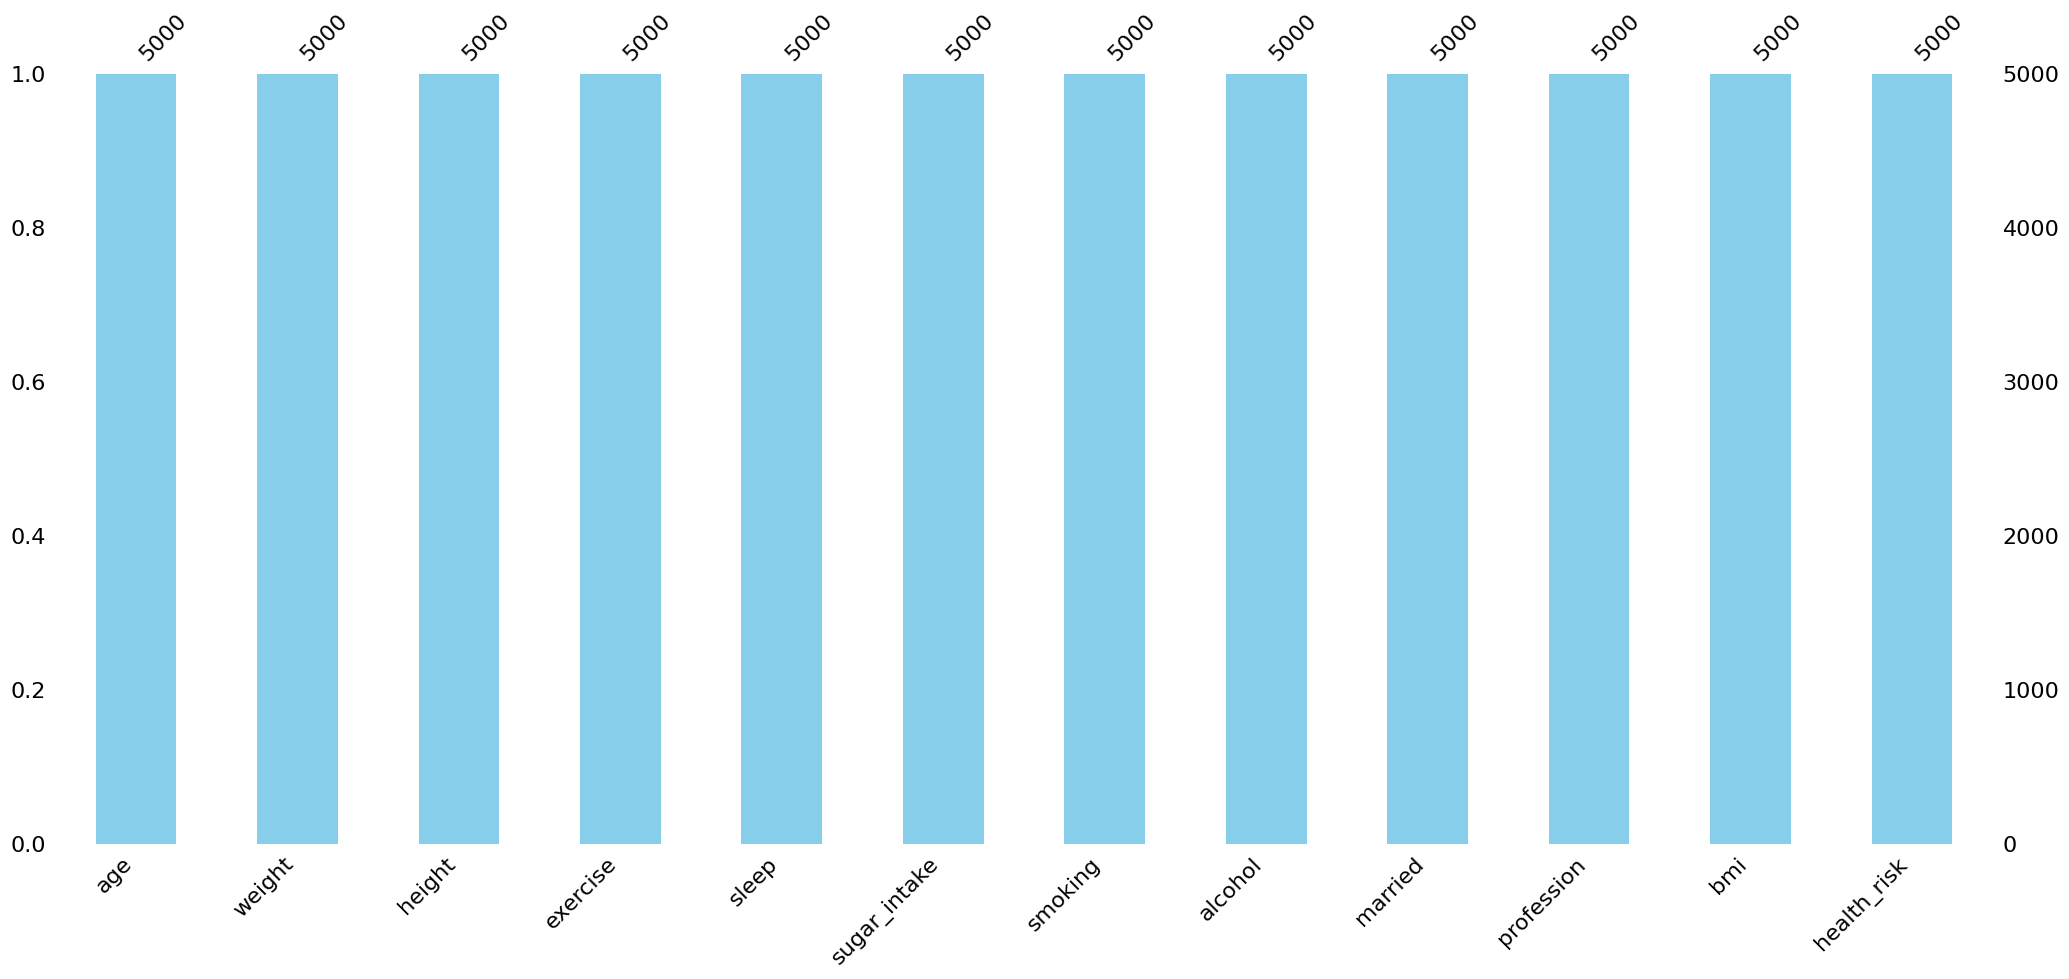

In [ ]:
# Show null in Columns
msno.bar(df, color='skyblue');

In [8]:
# Null Count in each column
print("Null Count in Each Column:")
df.isnull().sum()

Null Count in Each Column:


age             0
weight          0
height          0
exercise        0
sleep           0
sugar_intake    0
smoking         0
alcohol         0
married         0
profession      0
bmi             0
health_risk     0
dtype: int64

* * `Comment: No Missing in Dataset`

In [9]:
# show Duplicate Rows
print("Number of Duplicate Rows:", df.duplicated().sum())

Number of Duplicate Rows: 0


### Show the Correlation

<Axes: >

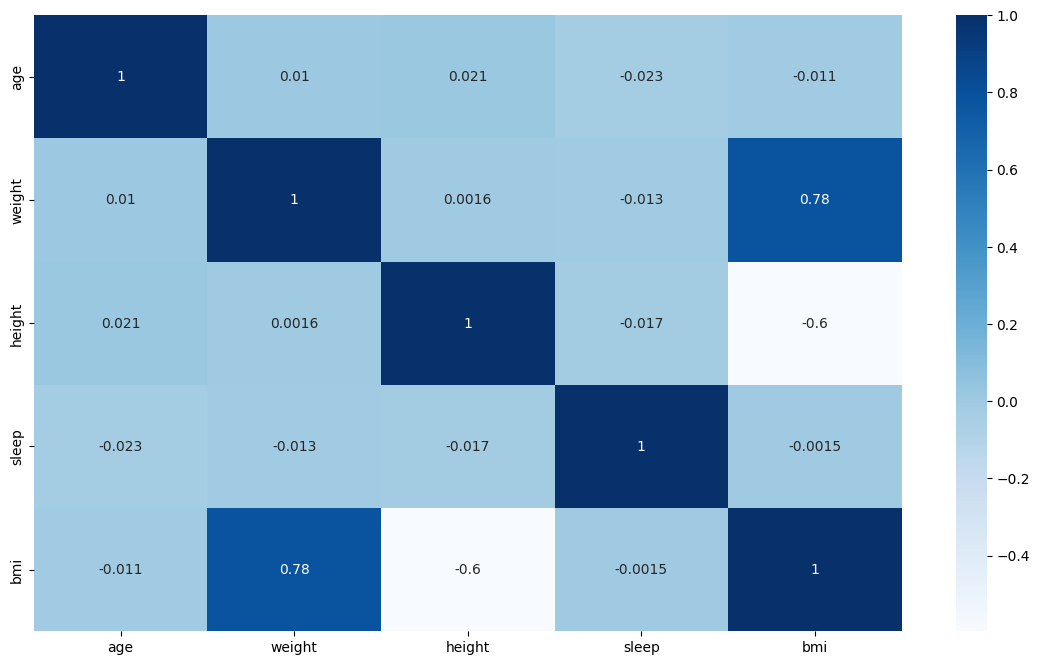

In [10]:
# Change the shape of plot
plt.figure(figsize=(14, 8))

# Create a Heatmap of the Correlation Matrix
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Blues')

# Data Visualization

C:\Users\EngMo\AppData\Local\Temp\ipykernel_9780\3031255408.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="health_risk", data=df, palette='Set1')


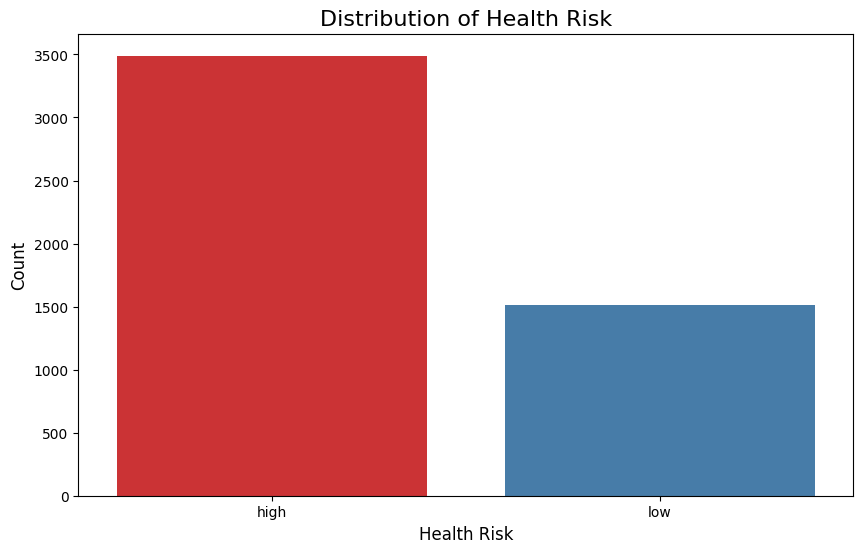

In [11]:
# Change the Shape of Plot
plt.figure(figsize=(10, 6))

# Create countplot for 'disease_risk' using seaborn
sns.countplot(x="health_risk", data=df, palette='Set1')

# Titl of the Plot
plt.title("Distribution of Health Risk", fontsize=16)

# Name of X and Y axis
plt.xlabel("Health Risk", fontsize=12)
plt.ylabel("Count", fontsize=12)

# Show the Plot
plt.show()

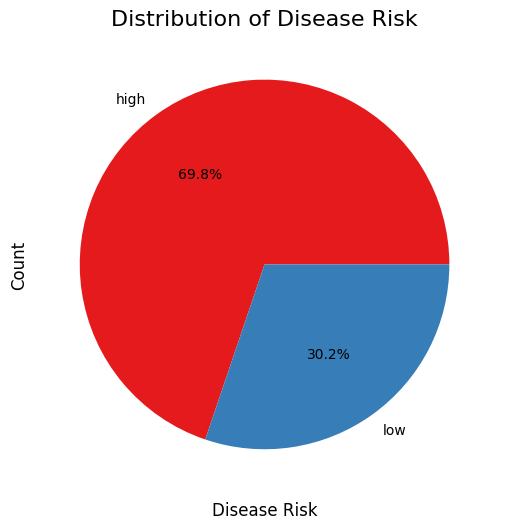

In [ ]:
# Change the Shape of Plot
plt.figure(figsize=(10, 6))

# Create Pie Chart for 'disease_risk' using seaborn
disease_risk_counts = df['health_risk'].value_counts()
plt.pie(disease_risk_counts, labels=disease_risk_counts.index, autopct='%1.1f%%', colors=sns.color_palette('Set1'))

# Titl of the Plot
plt.title("Distribution of Disease Risk", fontsize=16)

# Name of X and Y axis
plt.xlabel("Disease Risk", fontsize=12)
plt.ylabel("Count", fontsize=12)

# Show the Plot
plt.show()

* > `Comment: The disease_risk is inbalance. (Major class for disease)`

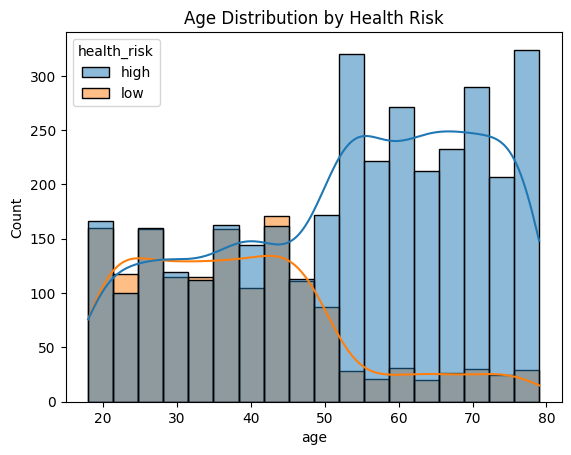

In [12]:
sns.histplot(data=df, x="age", hue="health_risk", kde=True)
plt.title("Age Distribution by Health Risk")
plt.show()

### Split the Dataset

In [13]:
# Split the dataset into features (X) and target variable (y)
X = df.drop(columns=["health_risk"])
y = df["health_risk"]

# Split the dataset into training and testing sets with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Display the shapes of the training and testing sets
print("Training set shape:", X_train.shape, y_train.shape)
print("Testing set shape:", X_test.shape, y_test.shape)

Training set shape: (4000, 11) (4000,)
Testing set shape: (1000, 11) (1000,)


In [14]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from xgboost import XGBClassifier

# categorical columns
categorical_columns = [
    "exercise", "sugar_intake", "smoking",
    "alcohol", "married", "profession"
]

# numerical columns (أي حاجة مش categorical)
numerical_columns = [col for col in X_train.columns if col not in categorical_columns]

# preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), categorical_columns),
        ("num", StandardScaler(), numerical_columns)
    ]
)

# pipeline كامل
pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", XGBClassifier(
        n_estimators=200,
        max_depth=7,
        learning_rate=0.01,
    ))
])

In [15]:
y_train = y_train.str.strip().str.lower()
y_test = y_test.str.strip().str.lower()

In [16]:
y_train = y_train.map({"low": 0, "high": 1})
y_test = y_test.map({"low": 0, "high": 1})

In [17]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['exercise', 'sugar_intake',
                                                   'smoking', 'alcohol',
                                                   'married', 'profession']),
                                                 ('num', StandardScaler(),
                                                  ['age', 'weight', 'height',
                                                   'sleep', 'bmi'])])),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               col...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.01,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=7, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [18]:
import joblib

joblib.dump(pipeline, "full_pipeline.pkl")

['full_pipeline.pkl']

In [ ]:
pipeline = joblib.load("full_pipeline.pkl")

prediction = pipeline.predict(X_test)

In [ ]:
accuracy_score(y_test,prediction)

0.991

### Preprocessing

###  *Encode Target*

In [ ]:
y_train = y_train.map({"low":0, "high":1})
y_test = y_test.map({"low":0, "high":1})

*Encode Categorical Features*

In [ ]:
categorical_columns = ["exercise",
                       "sugar_intake", "smoking", "alcohol",
                       "married", "profession"]

label_encoder = LabelEncoder()

for col in categorical_columns:
  X_train[col] = label_encoder.fit_transform(X_train[col])
  X_test[col] = label_encoder.transform(X_test[col])

*Feature scaling*

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Build Models

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=7, random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=7,
        learning_rate=0.01,
    )
}

### Train each model & Compare Result

In [ ]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = recall_score(y_test, y_pred)
    results[name] = acc

### Show result

In [ ]:
for model_name, score in results.items():
  print(model_name, "Recall:", score)

Logistic Regression Recall: 0.9040114613180515
Random Forest Recall: 0.9828080229226361
XGBoost Recall: 0.994269340974212


### Choose best Model

In [ ]:
best_model = max(results, key=results.get)
print("Best Model:", best_model)

Best Model: XGBoost


### Build Neural Network

In [ ]:
model = tf.keras.Sequential([
    layers.Dense(256, activation="relu", input_shape=(X_train.shape[1],)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(1, activation="sigmoid")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Compile

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall(),
        tf.keras.metrics.AUC()
        ]
)

### Early Stopping

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor = 'val_loss',
    patience = 10,
    restore_best_weights = True
    )

### Process imbalance in data

In [ ]:
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))


### Training

In [ ]:
history = model.fit(
      X_train, y_train,
      validation_split=0.2,
      epochs=200,
      batch_size=32,
      callbacks=[early_stop],
      class_weight=class_weights
  )

Epoch 1/200
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.6499 - auc: 0.7369 - loss: 0.6266 - precision: 0.8389 - recall: 0.6104 - val_accuracy: 0.7225 - val_auc: 0.8981 - val_loss: 0.5367 - val_precision: 0.9557 - val_recall: 0.6416
Epoch 2/200
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7843 - auc: 0.8822 - loss: 0.4275 - precision: 0.9134 - recall: 0.7652 - val_accuracy: 0.7763 - val_auc: 0.9059 - val_loss: 0.4510 - val_precision: 0.9338 - val_recall: 0.7395
Epoch 3/200
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8037 - auc: 0.9029 - loss: 0.3940 - precision: 0.9251 - recall: 0.7785 - val_accuracy: 0.8200 - val_auc: 0.9169 - val_loss: 0.3826 - val_precision: 0.9421 - val_recall: 0.7972
Epoch 4/200
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8054 - auc: 0.9068 - loss: 0.3805 - precision: 0.9289 - recall: 0.7840 - val_accuracy: 0.8050 - val_auc: 0.9194 - val_loss: 0.3805 - val_precision: 0.9581 - val_recall: 0.7605
Epoch 5/200
100/100 ━━━━━━━

### Evaluate Model

In [ ]:
loss, accuracy, precision, recall, auc = model.evaluate(X_test, y_test)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("AUC:", auc)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9703 - auc: 0.9976 - loss: 0.0620 - precision: 0.9864 - recall: 0.9710
Accuracy: 0.972000002861023
Precision: 0.9855072498321533
Recall: 0.9742120504379272
AUC: 0.9975900650024414


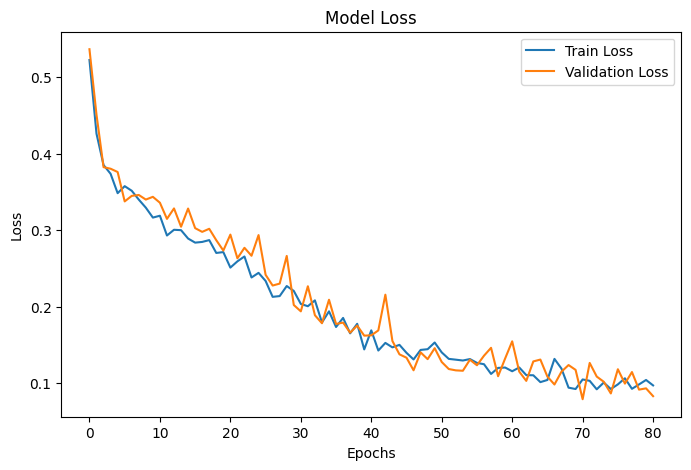

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")

plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()
plt.show()